# Data Cleaning Producers Direct dataset

Note about the raw dataset provided by Producers Direct:

The raw CSV file was around ~ 7 gb with over 20 million rows, and ultimately became inefficient to read directly into a notebook.

I utilized Google Colab to convert the CSV file into a Parquet file using DuckDB, resulting in newly converted Parquet file being used in this notebook.

## EDA on the Producers Direct dataset

In [26]:
import os 
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [27]:
current_directory = Path(os.getcwd())

parquet_file_path =  current_directory.joinpath('../data/b0cd514b-b9cc-4972-a0c2-c91726e6d825.parquet')

In [28]:
# Getting summary stats of data.
conn = duckdb.connect()

df_schema = conn.execute(f"DESCRIBE '{parquet_file_path}'").fetchdf()
print(df_schema)

                   column_name               column_type null   key default  \
0                  question_id                    BIGINT  YES  None    None   
1             question_user_id                    BIGINT  YES  None    None   
2            question_language                   VARCHAR  YES  None    None   
3             question_content                   VARCHAR  YES  None    None   
4               question_topic                   VARCHAR  YES  None    None   
5                question_sent  TIMESTAMP WITH TIME ZONE  YES  None    None   
6                  response_id                    BIGINT  YES  None    None   
7             response_user_id                    BIGINT  YES  None    None   
8            response_language                   VARCHAR  YES  None    None   
9             response_content                   VARCHAR  YES  None    None   
10              response_topic                   VARCHAR  YES  None    None   
11               response_sent  TIMESTAMP WITH TIME 

In [29]:
# Summary counts of the whole records and specific columns.
query_summary = f"""
    SELECT
        COUNT(*) AS total_records,
        COUNT(DISTINCT question_language) AS distinct_question_languages,
        COUNT(DISTINCT question_topic) AS distinct_question_topics,
        COUNT(DISTINCT response_topic) AS distinct_response_topics,
    FROM '{parquet_file_path}';
"""

query_summary_record = conn.execute(query_summary).fetchdf()
print("\n Summary Record:")
print(query_summary_record)


 Summary Record:
   total_records  distinct_question_languages  distinct_question_topics  \
0       20304843                            4                       148   

   distinct_response_topics  
0                       150  


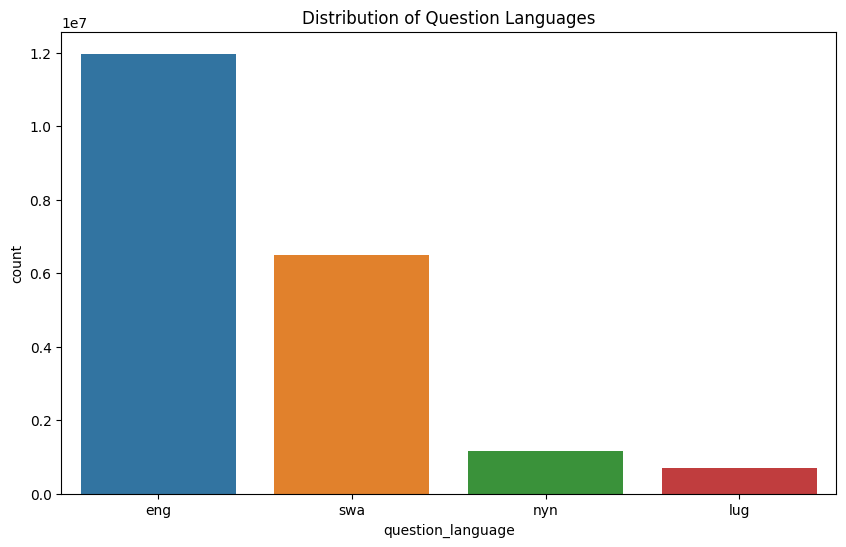

In [30]:
# Bar plot visualization of language distribution in the dataset.

conn.sql(f"""
    CREATE TEMP VIEW all_data AS
    SELECT *
    FROM '{parquet_file_path}'
""")

query_lang_distrib = f"""
    SELECT 
        question_language,
        COUNT(*) AS count,
    FROM all_data
    GROUP BY
        question_language,
    ORDER BY
        count DESC;
"""
lang_distrib = conn.execute(query_lang_distrib).fetchdf()

plt.figure(figsize=(10, 6))
sns.barplot(lang_distrib, x='question_language', y='count', hue='question_language')
plt.title('Distribution of Question Languages')
plt.show()

In [31]:
# Querying to get the top ten topics and converting them into a list

query_top_ten_topics = f"""
    SELECT
        question_topic,
        COUNT(*) AS count
    FROM all_data
    GROUP BY
        question_topic,
    ORDER BY
        count DESC
    LIMIT 10;
"""
top_ten_topics = conn.execute(query_top_ten_topics).fetchdf()

top_ten_topics_list = list(top_ten_topics.iloc[:, 0])
top_ten_topics

,question_topic,count
0,None,3537729
1,maize,2201755
2,cattle,1675473
3,chicken,1667251
4,tomato,1096386
5,poultry,1051797
6,plant,1024498
7,bean,732120
8,crop,602913
9,goat,434284


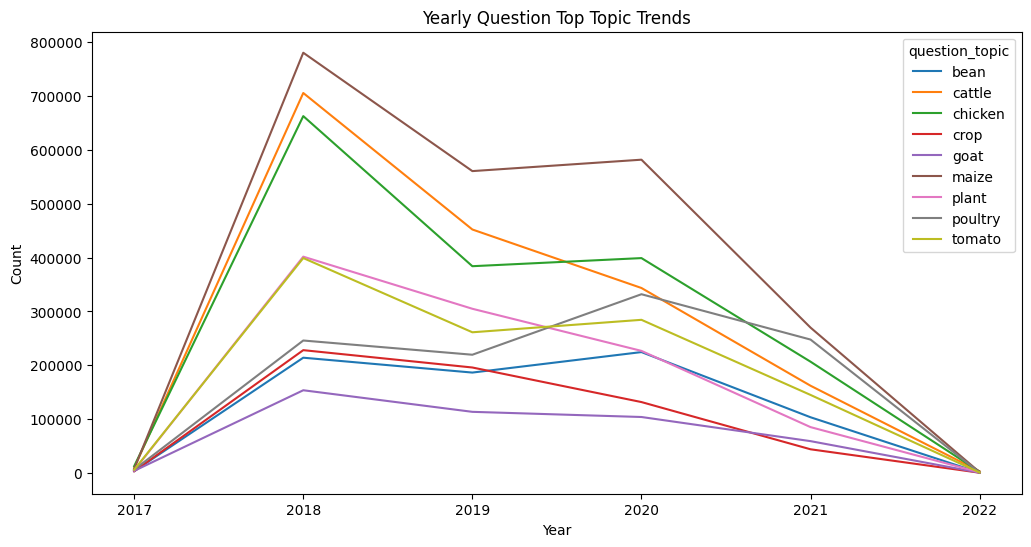

In [32]:
# Visualizing line plot of the yearly top topic trends

query_yearly_top_topics = f"""
    SELECT
        strftime(question_sent, '%Y') AS year,
        question_topic,
        COUNT(*) AS count
    FROM all_data
    WHERE question_topic IN ({','.join([f"'{topic}'" for topic in top_ten_topics_list])})
    GROUP BY
        year,
        question_topic,
    ORDER BY
        year,
        question_topic;
"""

yearly_top_topics = conn.execute(query_yearly_top_topics).fetchdf()

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_top_topics, x='year', y='count', hue='question_topic')
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Yearly Question Top Topic Trends')
plt.show()

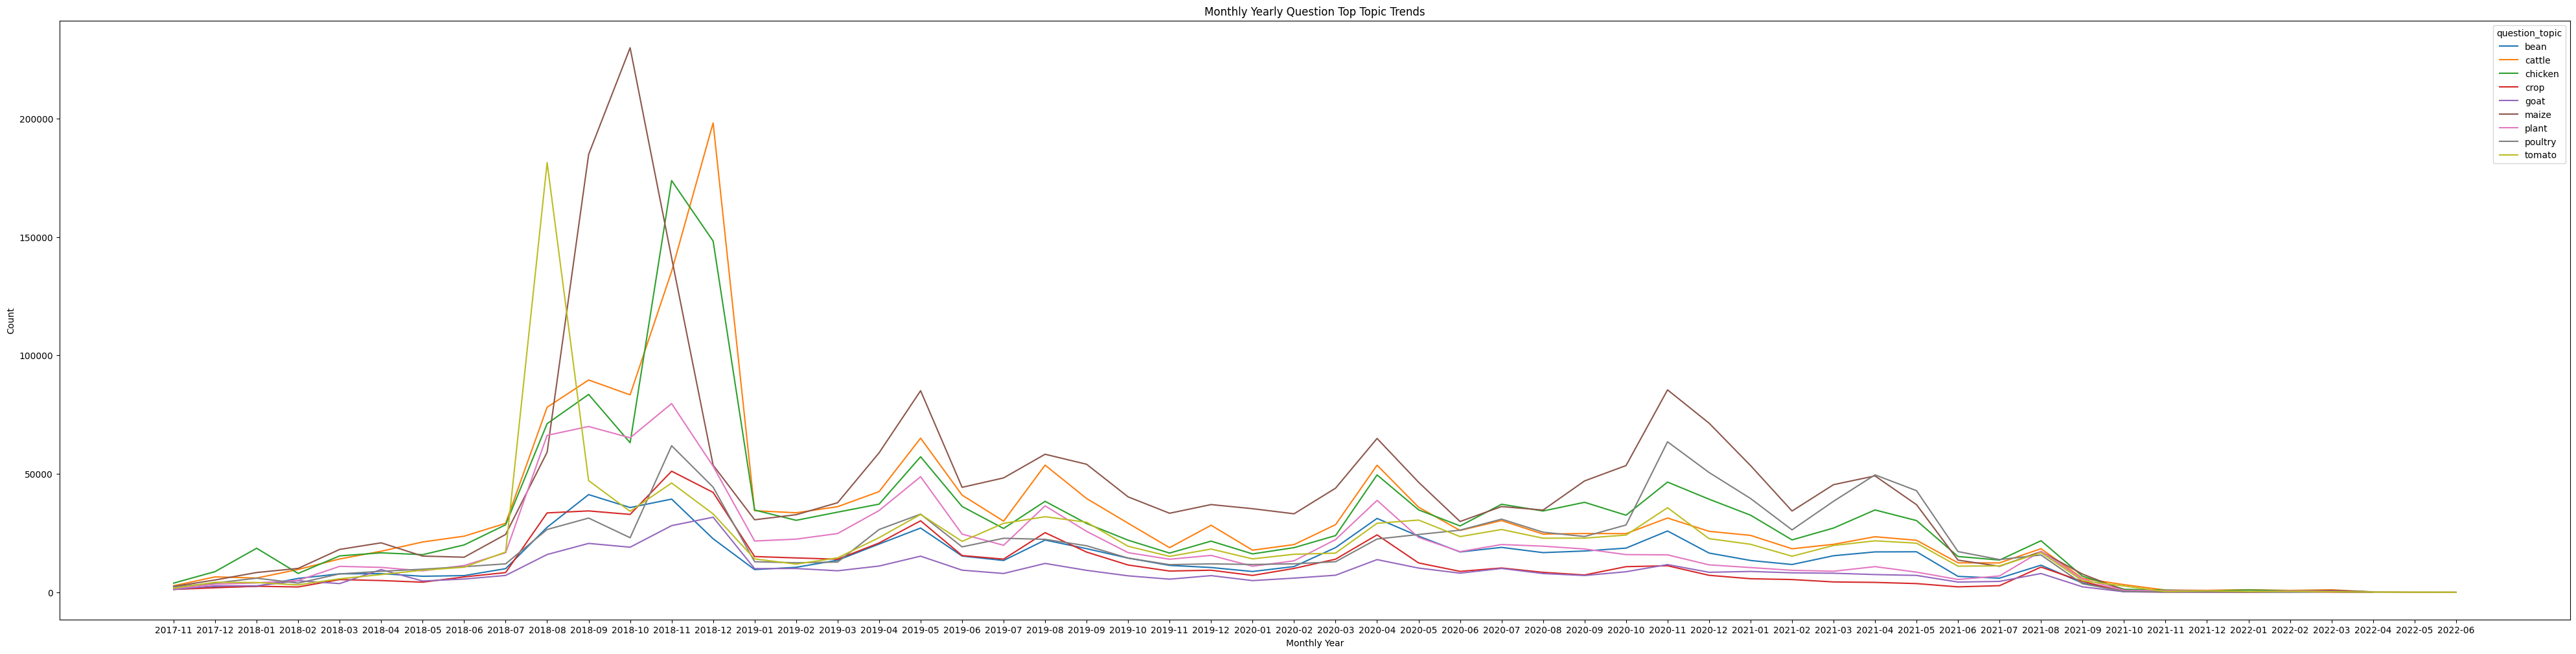

In [33]:
# Visualizing line plot of Month and Year top topic trends from 2017-2022 

query_monthly_top_topics = f"""
    SELECT
        strftime(question_sent, '%Y-%m') AS year_month,
        question_topic,
        COUNT(*) AS count
    FROM all_data
    WHERE question_topic IN ({','.join([f"'{topic}'" for topic in top_ten_topics_list])})
    GROUP BY
        year_month,
        question_topic
    ORDER BY
        year_month,
        question_topic;
"""

monthly_top_topics = conn.execute(query_monthly_top_topics).fetchdf()

plt.figure(figsize=(50, 12))
sns.lineplot(data=monthly_top_topics, x='year_month', y='count', hue='question_topic')
plt.xlabel('Monthly Year')
plt.ylabel('Count')
plt.title('Monthly Yearly Question Top Topic Trends')
plt.show()

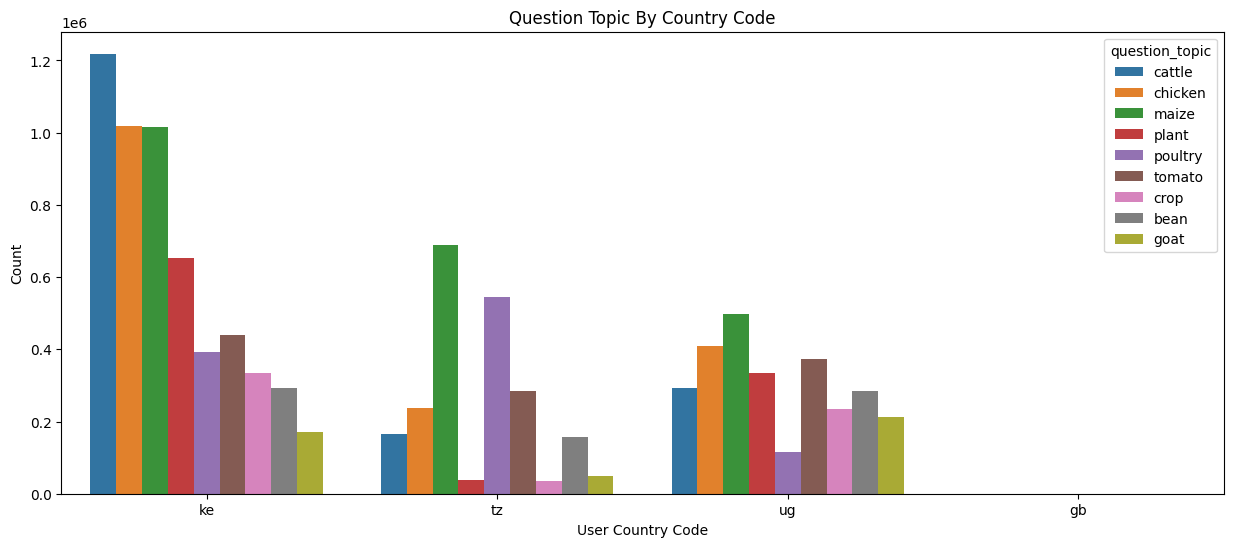

In [34]:
# Visualizing bar plot of question topics by country code

query_country_topic = f"""
    SELECT 
        question_topic,
        question_user_country_code,
        COUNT(*) AS count
    FROM all_data
    WHERE question_topic IN ({','.join([f"'{topic}'" for topic in top_ten_topics_list])})
    GROUP BY 
        question_topic,
        question_user_country_code
    ORDER BY 
        count DESC
"""

country_topic = conn.execute(query_country_topic).fetchdf()

plt.figure(figsize=(15, 6))
sns.barplot(data=country_topic, x='question_user_country_code', y='count', hue='question_topic')
plt.xlabel('User Country Code')
plt.ylabel('Count')
plt.title('Question Topic By Country Code')
plt.show()
conn.close()